# Notebook 03: Feature transformations

Before committing to a single transform, we compare six approaches using the same 10-fold CV setup used for outlier handling. Each method is applied to a copy of the cleaned `housing_df`; the original is never modified.

- `none`: no transform; cleaned data as-is (baseline reference)
- `standard_scale`: zero mean, unit variance per feature
- `log1p`: `log(x + 1)` per feature (shift applied if min < 0), then standard-scaled
- `sqrt`: square root per feature (shift if min < 0), then standard-scaled
- `yeo_johnson`: `PowerTransformer(method='yeo-johnson')`; fits the best Box-Cox-style λ per feature, handles negatives
- `quantile_normal`: `QuantileTransformer(output_distribution='normal')`; maps each feature's empirical CDF to a standard normal

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import DATA_DIR, LOG_FEATURES, PIPELINE_COLORS, PIPELINE_RESULTS_PATH

## 2. Data loading

In [2]:
in_path = DATA_DIR / '02-outlier-cleaning.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 02-outlier-cleaning.ipynb ' +
         'first to generate data/02-outlier-cleaning.csv.')
    )

housing_df = pd.read_csv(in_path)
features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/fsa-feature-engineering-challenge/02-outlier-cleaning.csv


## 3. Feature transformation methods

In [3]:
cv_log_feature_results = fl.run_per_feature_scan(
    housing_df,
    features,
    lambda s: np.log1p(s + max(0.0, -s.min())),
    'log',
    target='MedHouseVal',
 )

cv_sqrt_feature_results = fl.run_per_feature_scan(
    housing_df,
    features,
    lambda s: np.sqrt(s + max(0.0, -s.min())),
    'sqrt',
    target='MedHouseVal',
 )

power_transformer = PowerTransformer(method='yeo-johnson')

cv_power_feature_results = fl.run_per_feature_scan(
    housing_df,
    features,
    lambda s: power_transformer.fit_transform(
        ((s - s.min() + 1.0) if (s.max() <= 0) else s).to_frame()
    ).ravel(),
    'power',
    target='MedHouseVal',
 )

quantile_transformer = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=500,
    random_state=315
 )

cv_quantile_feature_results = fl.run_per_feature_scan(
    housing_df,
    features,
    lambda s: quantile_transformer.fit_transform(s.to_frame()).ravel(),
    'quantile',
    target='MedHouseVal',
 )

Baseline R2 (in-sample): 0.6739

    log_MedInc: r = -0.0283,  p = 0.0000
  log_HouseAge: r = +0.0019,  p = 0.7880
  log_AveRooms: r = -0.0292,  p = 0.0000
 log_AveBedrms: r = -0.0005,  p = 0.9446
log_Population: r = -0.0198,  p = 0.0045
  log_AveOccup: r = -0.0236,  p = 0.0007
  log_Latitude: r = -0.0003,  p = 0.9659
 log_Longitude: r = +0.0094,  p = 0.1790
Baseline R2 (in-sample): 0.6739

    sqrt_MedInc: r = -0.0183,  p = 0.0087
  sqrt_HouseAge: r = +0.0004,  p = 0.9536
  sqrt_AveRooms: r = -0.0175,  p = 0.0120
 sqrt_AveBedrms: r = -0.0005,  p = 0.9464
sqrt_Population: r = -0.0071,  p = 0.3075
  sqrt_AveOccup: r = -0.0159,  p = 0.0227
  sqrt_Latitude: r = -0.0002,  p = 0.9811
 sqrt_Longitude: r = +0.0067,  p = 0.3393
Baseline R2 (in-sample): 0.6739



    power_MedInc: r = -0.0307,  p = 0.0000
  power_HouseAge: r = -0.0000,  p = 0.9949


  power_AveRooms: r = -0.0222,  p = 0.0015
 power_AveBedrms: r = -0.0023,  p = 0.7409


power_Population: r = -0.0098,  p = 0.1596
  power_AveOccup: r = -0.0309,  p = 0.0000


  power_Latitude: r = -0.0000,  p = 0.9978
 power_Longitude: r = -0.0021,  p = 0.7676
Baseline R2 (in-sample): 0.6739

    quantile_MedInc: r = -0.0225,  p = 0.0012
  quantile_HouseAge: r = +0.0352,  p = 0.0000
  quantile_AveRooms: r = -0.0044,  p = 0.5287


 quantile_AveBedrms: r = +0.0134,  p = 0.0546
quantile_Population: r = -0.0111,  p = 0.1111
  quantile_AveOccup: r = -0.0060,  p = 0.3894
  quantile_Latitude: r = +0.0279,  p = 0.0001
 quantile_Longitude: r = -0.0426,  p = 0.0000


## 4. Plotting configuration

In [4]:
configs = [
    (
        'log',
        'log1p',
        cv_log_feature_results,
        '#5b9bd5',
        lambda s: np.log1p(s + max(0.0, -s.min()))
    ),(
        'sqrt',
        'sqrt',
        cv_sqrt_feature_results,
        '#70ad47',
        lambda s: np.sqrt(s + max(0.0, -s.min()))
    ),(
        'power',
        'power/Yeo-Johnson',
        cv_power_feature_results,
        '#ed7d31',
        lambda s: power_transformer.fit_transform(
            ((s - s.min() + 1.0) if (s.max() <= 0) else s).to_frame()
        ).ravel()
    ),(
        'quantile',
        'quantile/normal',
        cv_quantile_feature_results,
        '#7030a0',
        lambda s: quantile_transformer.fit_transform(s.to_frame()).ravel()
    ),
]


## 5. Per-feature transform results

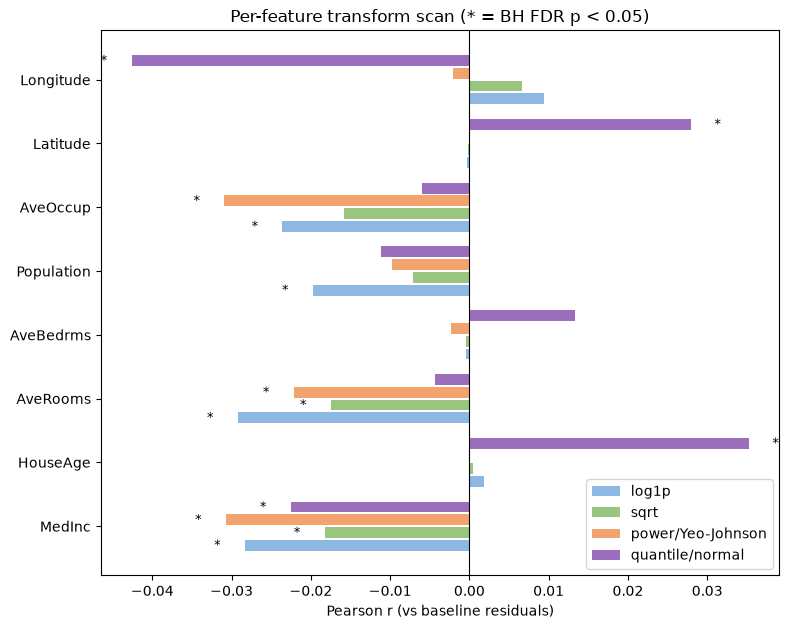

In [5]:
sig_dict = fl.plot_combined_per_feature_scan(
    configs,
    title='Per-feature transform scan (* = BH FDR p < 0.05)'
)

## 6. Significant transforms vs baseline residuals

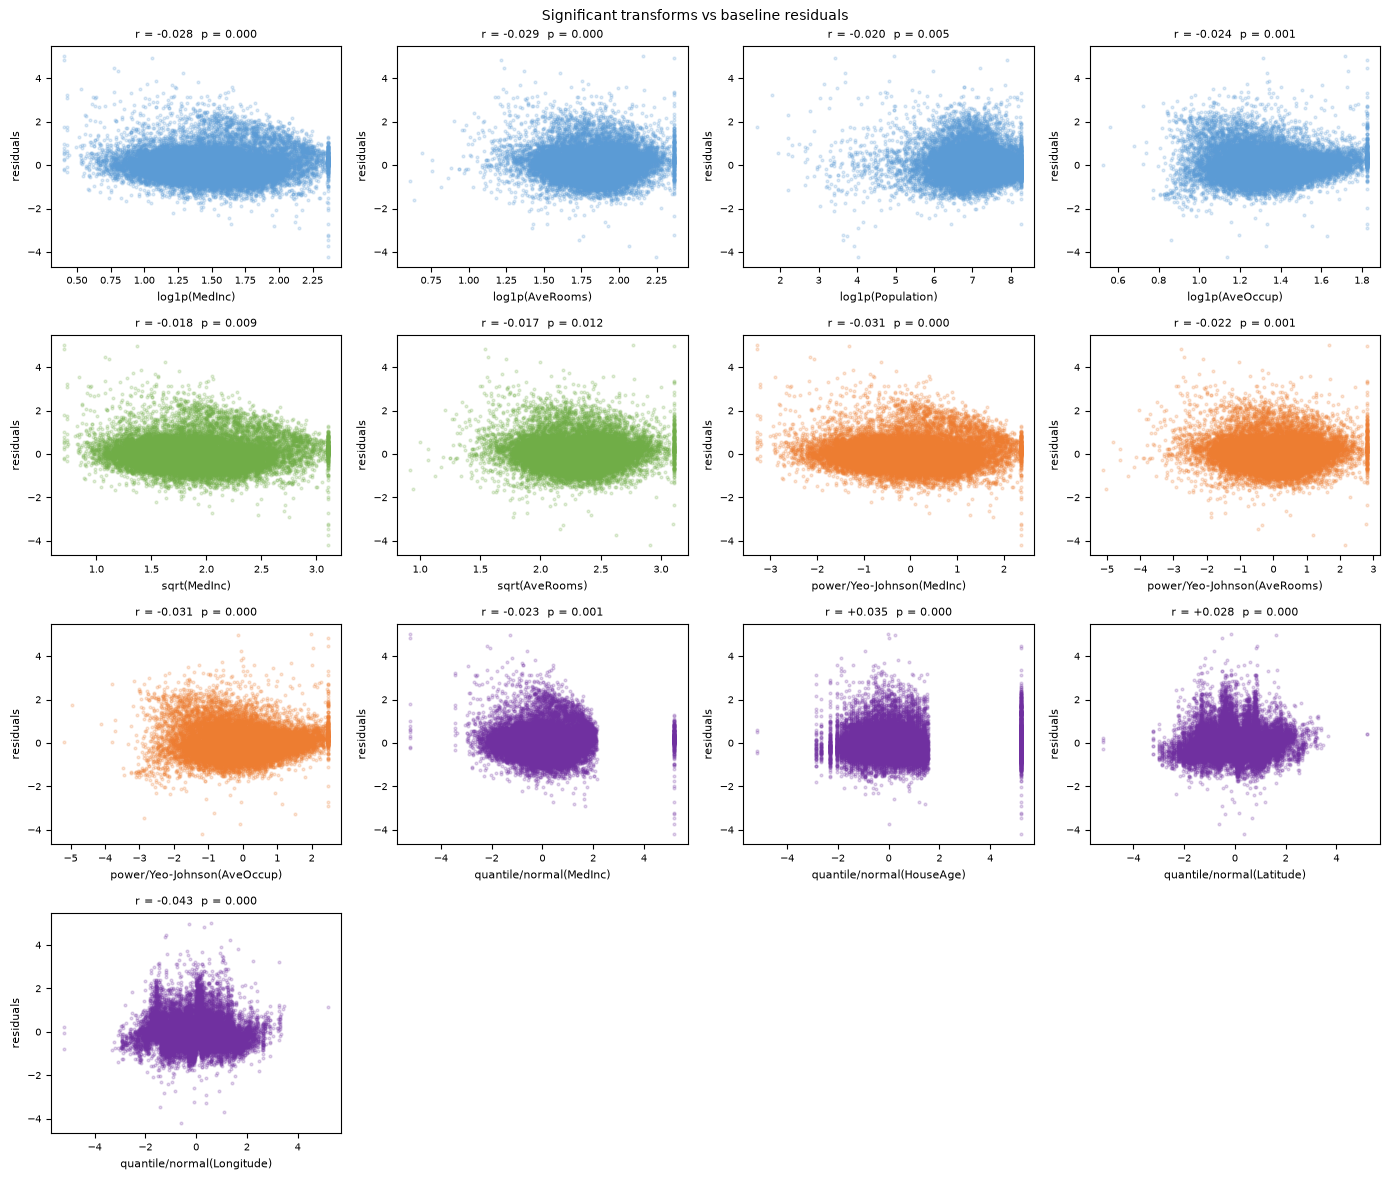

In [6]:
fl.plot_significant_transform_scatters(
    configs,
    sig_dict,
    housing_df,
    title='Significant transforms vs baseline residuals',
    target='MedHouseVal',
)

## 7. Transform features

In [7]:
for col in LOG_FEATURES:
    col_min = housing_df[col].min()
    shift = -col_min if col_min < 0 else 0
    housing_df[col] = np.log1p(housing_df[col] + shift)

print(f'Applied log1p to: {LOG_FEATURES}')

Applied log1p to: ['AveRooms', 'AveOccup']


## 8. Performance evaluation

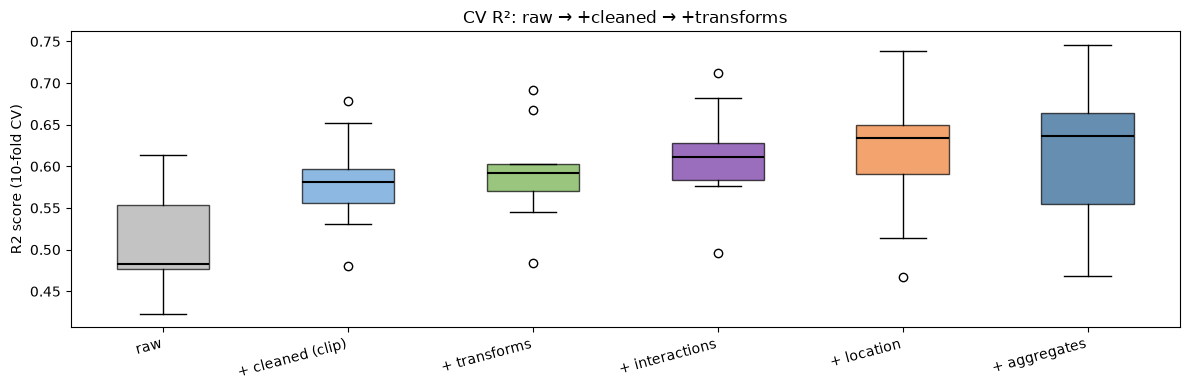

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)


In [8]:
results_df = fl.add_pipeline_step(
    None,
    '+ transforms',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ transforms', '#70ad47'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → +cleaned → +transforms',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 9. Save output

In [9]:
out_path = DATA_DIR / '03-feature-transformations.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/fsa-feature-engineering-challenge/03-feature-transformations.csv
